
### **Random Fourier Features (RFF) Toy Example with gpytorch**

This notebook provides a practical demonstration of Random Fourier Features (RFF), a technique introduced by Rahimi and Recht (2007) to approximate shift-invariant kernels (like the RBF kernel) using low-dimensional random projections. The core idea is to replace the expensive kernel matrix computation with a linear model in a randomly projected feature space, significantly speeding up training and inference for large datasets.

#### **Theoretical Background**

Kernel methods implicitly map data into a high-dimensional (possibly infinite) feature space $V$ where relationships become linear. The kernel function $k(x, y)$ computes the inner product $\langle \phi(x), \phi(y) \rangle$ in this space without explicitly calculating $\phi(x)$.

However, for $N$ data points, the kernel matrix $K$ is $N \times N$, and operations like inversion have $O(N^3)$ complexity, which becomes prohibitive for large $N$. RFF addresses this by approximating the kernel using a randomized feature map $z: \mathcal{X} \rightarrow \mathbb{R}^D$ such that:
$$
k(x, y) \approx z(x)^\top z(y)
$$
where $D \ll N$. This allows us to perform standard linear regression or use linear models within `gpytorch`, reducing the complexity from $O(N^3)$ to $O(N D^2)$.

##### **Unbiasedness of the RFF Approximation**

A key property of RFF is that it provides an *unbiased* estimator of the kernel. Let's prove this for the phase-shifted cosine variant (Eq. 15 from the paper):

Define the single-feature map as:
$$
z_\omega(x) = \cos(\omega^\top x + b)
$$
where $\omega \sim p(\omega)$ and $b \sim \text{Uniform}(0, 2\pi)$.

The expected value of the dot product for two points $x$ and $y$ is:
$$
\mathbb{E}_{\omega, b}[z_\omega(x) z_\omega(y)] = \mathbb{E}_{\omega, b}[\cos(\omega^\top x + b) \cos(\omega^\top y + b)]
$$

Using the trigonometric identity $\cos(A)\cos(B) = \frac{1}{2}[\cos(A+B) + \cos(A-B)]$, we get:
$$
= \mathbb{E}_{\omega, b}\left[ \frac{1}{2} \left( \cos(\omega^\top (x+y) + 2b) + \cos(\omega^\top (x-y)) \right) \right]
$$

Since $b$ is uniform on $[0, 2\pi]$, the expectation over $b$ of $\cos(\omega^\top (x+y) + 2b)$ is zero:
$$
\mathbb{E}_b[\cos(\omega^\top (x+y) + 2b)] = 0
$$

Therefore, the expectation simplifies to:
$$
\mathbb{E}_{\omega, b}[z_\omega(x) z_\omega(y)] = \mathbb{E}_\omega\left[ \frac{1}{2} \cos(\omega^\top (x-y)) \right]
$$

For the RBF kernel, $p(\omega)$ is a Gaussian distribution, and its Fourier transform gives the kernel:
$$
k(x, y) = \mathbb{E}_\omega[\cos(\omega^\top (x-y))]
$$

Thus, for a single feature, we have:
$$
\mathbb{E}_{\omega, b}[z_\omega(x) z_\omega(y)] = \frac{1}{2} k(x, y)
$$

To make the approximation unbiased, we define the full feature map for $D$ features as:
$$
z(x) = \sqrt{\frac{2}{D}} \begin{bmatrix} z_{\omega_1}(x) \\ z_{\omega_2}(x) \\ \vdots \\ z_{\omega_D}(x) \end{bmatrix}
$$

Then, the expected value of the dot product is:
$$
\mathbb{E}[z(x)^\top z(y)] = \frac{2}{D} \sum_{d=1}^{D} \mathbb{E}_{\omega_d, b_d}[z_{\omega_d}(x) z_{\omega_d}(y)] = \frac{2}{D} \sum_{d=1}^{D} \frac{1}{2} k(x, y) = k(x, y)
$$

This proves that the RFF approximation is unbiased.

Here is the updated **Drawbacks of RFF** section, incorporating insights from the paper "On Feature Collapse and Deep Kernel Learning for Single Forward Pass Uncertainty" (van Amersfoort et al., 2022).

---

##### **Drawbacks of Random Fourier Features (RFF)**

While RFF provides a computationally efficient way to approximate kernel methods, it has several significant drawbacks, particularly when used in deep learning pipelines for uncertainty estimation.

1.  **Inadequate Uncertainty Estimation with Large Datasets**: As noted in the van Amersfoort et al. paper, the RFF approximation is *parametric*. This means that for any finite number of random features `D`, the approximated kernel is essentially a linear model in a `D`-dimensional space. A critical consequence of this is that as the number of training data points `N` increases, the uncertainty estimates provided by an RFF-based GP can become misleadingly narrow, even for data points far away from the training set. The paper illustrates this in Figure 1, where the RFF approximation (used in SNGP) shows wide uncertainty intervals for out-of-distribution data when trained on a small dataset (`1K` points), but these intervals collapse to near-zero uncertainty for the same out-of-distribution region when trained on a large dataset (`1M` points). This behavior is undesirable for applications like autonomous driving or medical diagnostics, where reliable uncertainty estimates are crucial for safety. In contrast, non-parametric methods like inducing point GPs maintain consistent uncertainty estimates regardless of dataset size.

2.  **Loss of Non-Parametric Properties**: The van Amersfoort et al. paper explicitly contrasts the RFF approximation with variational inducing point approximations. Inducing point GPs retain the non-parametric nature of the exact GP: they do not assume a fixed, finite-dimensional feature space. The RFF approximation sacrifices this property. While RFF is fast, this loss of non-parametricity directly contributes to its poor uncertainty calibration, especially as `N` grows large. The paper states: "The RFF approximation, while computationally fast, sacrifices the non-parametric property of the GP and is often avoided in the GP literature."


In summary, while RFF is a powerful tool for scaling kernel methods, its parametric nature makes it ill-suited for applications requiring robust, calibrated uncertainty estimates, especially with large datasets. For such tasks, non-parametric approximations like inducing point GPs are generally preferred, despite their higher computational cost.


In [1]:
# Import necessary libraries
import torch
import gpytorch
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)


# Generate synthetic 1D data
def generate_data(n_points=50):
    # Simple function to learn: f(x) = sin(2*pi*x) + noise
    x_train = torch.linspace(-1, 1, n_points).unsqueeze(-1)  # Shape: [n_points, 1]
    y_train = torch.sin(2 * np.pi * x_train.squeeze()) + 0.1 * torch.randn(n_points)
    return x_train, y_train


x_train, y_train = generate_data(n_points=50)

In [2]:
# Define the RFF Feature Map class
class RFFFeatureMap(torch.nn.Module):
    def __init__(self, input_dim, num_features, lengthscale=1.0):
        super(RFFFeatureMap, self).__init__()
        self.input_dim = input_dim
        self.num_features = num_features  # R (number of frequency pairs)
        self.lengthscale = lengthscale

        # Sample R random frequencies ω from N(0, 1/lengthscale^2)
        # Note: For RBF kernel k(x,y)=exp(-||x-y||^2 / (2*lengthscale^2)),
        # the spectral density p(ω) is N(0, I/lengthscale^2).
        self.omega = torch.randn(num_features, input_dim) / lengthscale
        # Sample R random phases b from Uniform(0, 2π)
        self.b = 2 * np.pi * torch.rand(num_features)

    def forward(self, x):
        # x shape: [batch_size, input_dim]
        # Compute ω^T x + b for all R features
        # Shape: [batch_size, num_features]
        omega_x_plus_b = torch.matmul(x, self.omega.t()) + self.b  # Broadcasting
        # Compute cos and sin components
        # Shape: [batch_size, 2*num_features]
        features = torch.cat(
            [torch.cos(omega_x_plus_b), torch.sin(omega_x_plus_b)], dim=1
        )
        # Normalize by sqrt(2/R) for unbiased estimation
        features = features * torch.sqrt(torch.tensor(2.0 / self.num_features))
        return features


# Create the RFF feature map instance
input_dim = 1
num_rff_features = 15  # 100  # R
rff_map = RFFFeatureMap(input_dim, num_rff_features, lengthscale=0.5)

In [3]:
# Define the GP Model using RFF approximation
class RFFGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, rff_map):
        super(RFFGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.LinearKernel(
                num_dims=2 * num_rff_features
            )  # Linear kernel in RFF space
        )
        self.rff_map = rff_map  # Store the RFF map

    def forward(self, x):
        # Transform input x using the RFF map
        projected_x = self.rff_map(x)
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(
            projected_x
        )  # Apply linear kernel on projected features
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


# Initialize likelihood and model for RFF GP
likelihood_rff = gpytorch.likelihoods.GaussianLikelihood()
model_rff = RFFGPModel(x_train, y_train, likelihood_rff, rff_map)


# Define the standard GP Model for comparison (using RBF kernel)
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


# Initialize likelihood and model for exact GP
likelihood_exact = gpytorch.likelihoods.GaussianLikelihood()
model_exact = ExactGPModel(x_train, y_train, likelihood_exact)

In [4]:
# Training the models
def train_model(
    model, likelihood, train_x, train_y, learning_rate=0.1, training_iter=50
):
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(training_iter):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        if (i + 1) % 10 == 0:
            print(f"Iter {i+1}/{training_iter} - Loss: {loss.item():.3f}")


print("Training Standard GP Model...")
train_model(
    model_exact, likelihood_exact, x_train, y_train, learning_rate=0.1, training_iter=50
)

print("\nTraining RFF GP Model...")
train_model(
    model_rff, likelihood_rff, x_train, y_train, learning_rate=0.1, training_iter=50
)

Training Standard GP Model...
Iter 10/50 - Loss: 0.667
Iter 20/50 - Loss: 0.297
Iter 30/50 - Loss: -0.101
Iter 40/50 - Loss: -0.365
Iter 50/50 - Loss: -0.429

Training RFF GP Model...
Iter 10/50 - Loss: 0.708
Iter 20/50 - Loss: 0.341
Iter 30/50 - Loss: -0.003
Iter 40/50 - Loss: -0.208
Iter 50/50 - Loss: -0.235


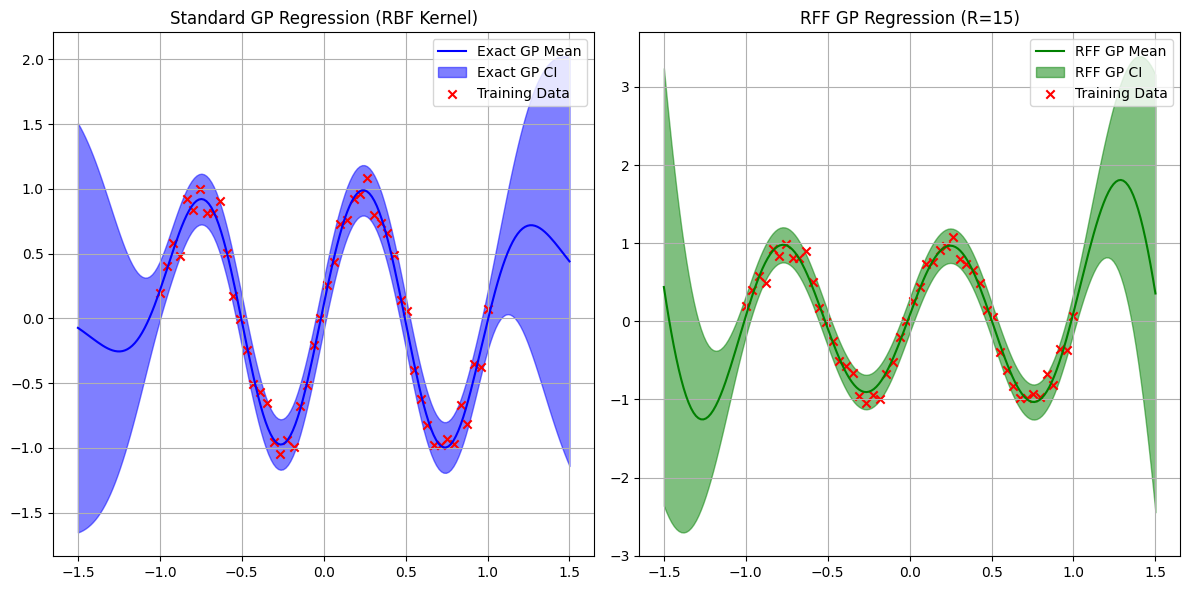

In [5]:
# Make predictions and plot results
# Set models to evaluation mode
model_exact.eval()
likelihood_exact.eval()
model_rff.eval()
likelihood_rff.eval()

# Create test points
test_x = torch.linspace(-1.5, 1.5, 200).unsqueeze(-1)

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Predictions for Exact GP
    exact_observed_pred = likelihood_exact(model_exact(test_x))
    exact_mean = exact_observed_pred.mean
    exact_lower, exact_upper = exact_observed_pred.confidence_region()

    # Predictions for RFF GP
    rff_observed_pred = likelihood_rff(model_rff(test_x))
    rff_mean = rff_observed_pred.mean
    rff_lower, rff_upper = rff_observed_pred.confidence_region()

# Plotting
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(test_x.numpy(), exact_mean.numpy(), "b", label="Exact GP Mean")
plt.fill_between(
    test_x.numpy().flatten(),
    exact_lower.numpy(),
    exact_upper.numpy(),
    alpha=0.5,
    color="b",
    label="Exact GP CI",
)
plt.scatter(
    x_train.numpy(), y_train.numpy(), c="red", marker="x", label="Training Data"
)
plt.title("Standard GP Regression (RBF Kernel)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(test_x.numpy(), rff_mean.numpy(), "g", label="RFF GP Mean")
plt.fill_between(
    test_x.numpy().flatten(),
    rff_lower.numpy(),
    rff_upper.numpy(),
    alpha=0.5,
    color="g",
    label="RFF GP CI",
)
plt.scatter(
    x_train.numpy(), y_train.numpy(), c="red", marker="x", label="Training Data"
)
plt.title(f"RFF GP Regression (R={num_rff_features})")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


--- Training RFF GP Model with 50 data points ---
Iter 10/50 - Loss: 0.752
Iter 20/50 - Loss: 0.367
Iter 30/50 - Loss: 0.011
Iter 40/50 - Loss: -0.210
Iter 50/50 - Loss: -0.251

--- Training RFF GP Model with 100 data points ---
Iter 10/50 - Loss: 0.710
Iter 20/50 - Loss: 0.259
Iter 30/50 - Loss: -0.149
Iter 40/50 - Loss: -0.377
Iter 50/50 - Loss: -0.416

--- Training RFF GP Model with 200 data points ---
Iter 10/50 - Loss: 0.610
Iter 20/50 - Loss: 0.149
Iter 30/50 - Loss: -0.252
Iter 40/50 - Loss: -0.479
Iter 50/50 - Loss: -0.528

--- Training RFF GP Model with 1000 data points ---
Iter 10/50 - Loss: 0.485
Iter 20/50 - Loss: 0.056
Iter 30/50 - Loss: -0.328
Iter 40/50 - Loss: -0.555
Iter 50/50 - Loss: -0.650


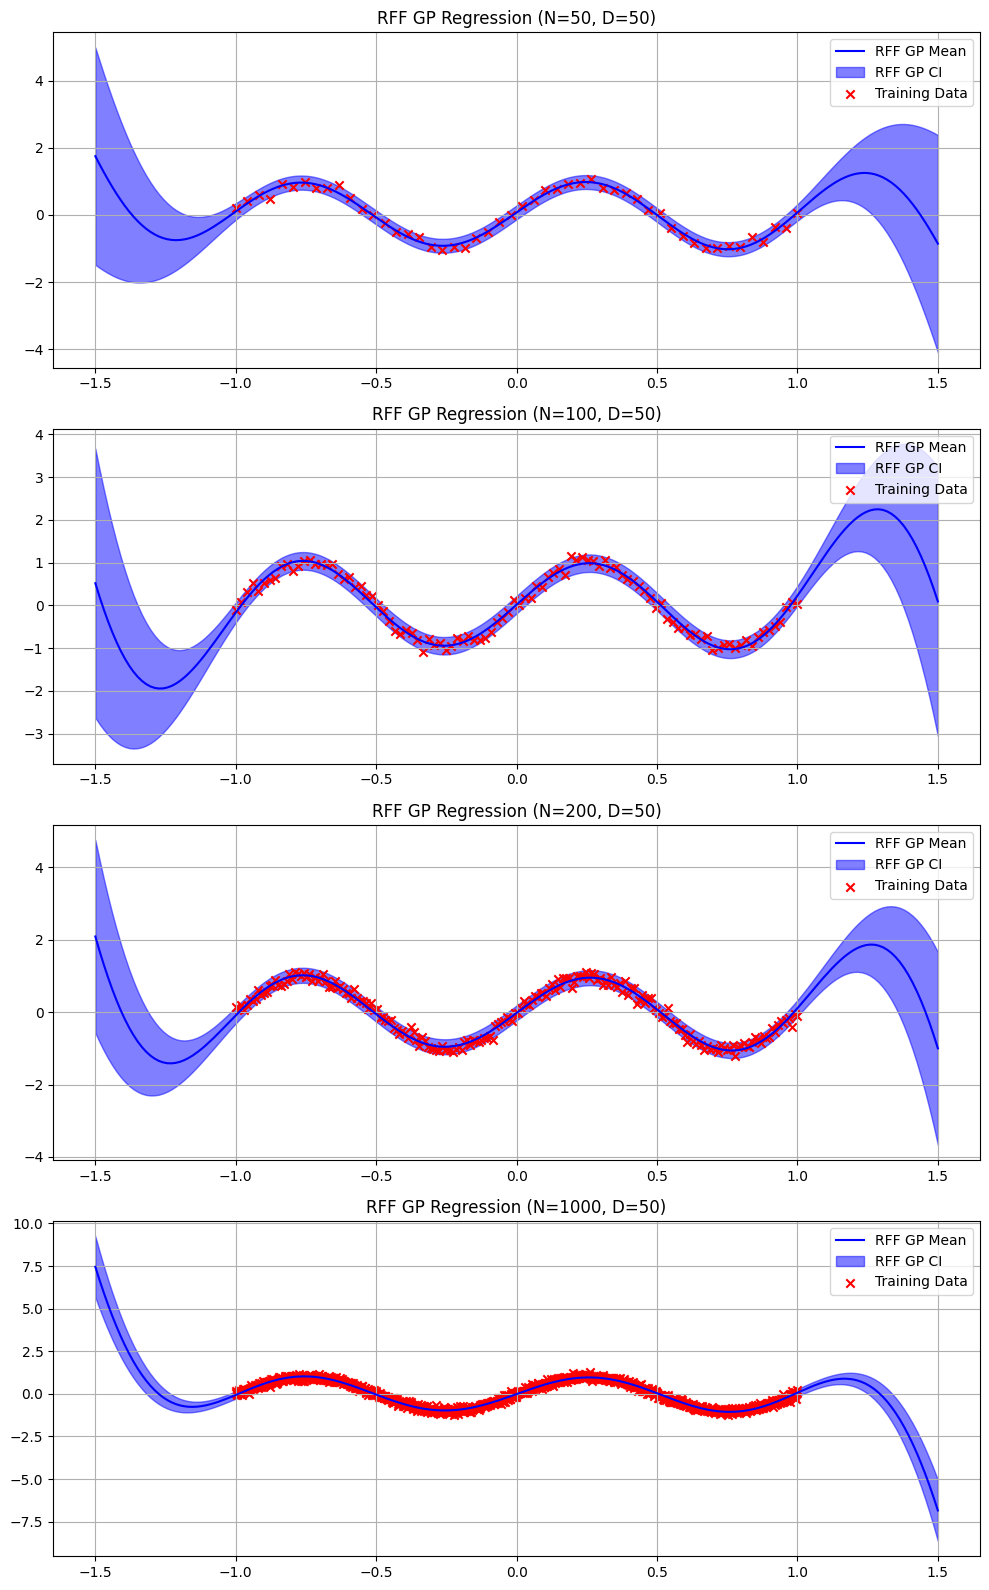

In [8]:
import torch
import gpytorch
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)


# Define the RFF Feature Map class
class RFFFeatureMap(torch.nn.Module):
    def __init__(self, input_dim, num_features, lengthscale=1.0):
        super(RFFFeatureMap, self).__init__()
        self.input_dim = input_dim
        self.num_features = num_features  # D (number of frequency pairs)
        self.lengthscale = lengthscale

        # Sample D random frequencies ω from N(0, 1/lengthscale^2)
        self.omega = torch.randn(num_features, input_dim) / lengthscale
        # Sample D random phases b from Uniform(0, 2π)
        self.b = 2 * np.pi * torch.rand(num_features)

    def forward(self, x):
        # x shape: [batch_size, input_dim]
        # Compute ω^T x + b for all D features
        omega_x_plus_b = torch.matmul(x, self.omega.t()) + self.b  # Broadcasting
        # Compute cos and sin components
        # Shape: [batch_size, 2*D]
        features = torch.cat(
            [torch.cos(omega_x_plus_b), torch.sin(omega_x_plus_b)], dim=1
        )
        # Normalize by sqrt(2/D) for unbiased estimation
        features = features * torch.sqrt(torch.tensor(2.0 / self.num_features))
        return features


# Define the GP Model using RFF approximation
class RFFGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, rff_map):
        super(RFFGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.LinearKernel(
                num_dims=2 * num_rff_features
            )  # Linear kernel in RFF space
        )
        self.rff_map = rff_map  # Store the RFF map

    def forward(self, x):
        # Transform input x using the RFF map
        projected_x = self.rff_map(x)
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(
            projected_x
        )  # Apply linear kernel on projected features
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


# Function to generate synthetic data
def generate_data(n_points=50):
    x_train = torch.linspace(-1, 1, n_points).unsqueeze(-1)  # Shape: [n_points, 1]
    y_train = torch.sin(2 * np.pi * x_train.squeeze()) + 0.1 * torch.randn(n_points)
    return x_train, y_train


# Function to train the model
def train_model(
    model, likelihood, train_x, train_y, learning_rate=0.1, training_iter=50
):
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(training_iter):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        if (i + 1) % 10 == 0:
            print(f"Iter {i+1}/{training_iter} - Loss: {loss.item():.3f}")


# Parameters
input_dim = 1
num_rff_features = 50  # D
lengthscale = 0.5

# Dataset sizes to compare
dataset_sizes = [50, 100, 200, 1000]

# Create test points
test_x = torch.linspace(-1.5, 1.5, 200).unsqueeze(-1)

# Plot results for different dataset sizes
fig, axes = plt.subplots(len(dataset_sizes), 1, figsize=(10, 4 * len(dataset_sizes)))

for idx, n_points in enumerate(dataset_sizes):
    print(f"\n--- Training RFF GP Model with {n_points} data points ---")

    # Generate data
    x_train, y_train = generate_data(n_points=n_points)

    # Create RFF map
    rff_map = RFFFeatureMap(input_dim, num_rff_features, lengthscale=lengthscale)

    # Initialize likelihood and model
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    model = RFFGPModel(x_train, y_train, likelihood, rff_map)

    # Train the model
    train_model(
        model, likelihood, x_train, y_train, learning_rate=0.1, training_iter=50
    )

    # Make predictions
    model.eval()
    likelihood.eval()

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        observed_pred = likelihood(model(test_x))
        mean = observed_pred.mean
        lower, upper = observed_pred.confidence_region()

    # Plot
    ax = axes[idx]
    ax.plot(test_x.numpy(), mean.numpy(), "b", label="RFF GP Mean")
    ax.fill_between(
        test_x.numpy().flatten(),
        lower.numpy(),
        upper.numpy(),
        alpha=0.5,
        color="b",
        label="RFF GP CI",
    )
    ax.scatter(
        x_train.numpy(), y_train.numpy(), c="red", marker="x", label="Training Data"
    )
    ax.set_title(f"RFF GP Regression (N={n_points}, D={num_rff_features})")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


### **Nystrom Approximation for Gaussian Processes**

The Nystrom approximation is a powerful technique for scaling kernel methods, including Gaussian Processes (GP), to large datasets. It addresses the computational bottleneck of inverting the full $N \times N$ kernel matrix $K$, which has an $O(N^3)$ complexity, by approximating it with a low-rank matrix derived from a smaller subset of data points.

#### **Theoretical Background**

Given a dataset $\mathcal{X} = \{x_1, x_2, ..., x_N\}$, the kernel matrix $K$ is defined as $K_{ij} = k(x_i, x_j)$, where $k(\cdot, \cdot)$ is a positive definite kernel function (e.g., the RBF kernel).

The Nystrom method selects a subset of $m$ "inducing points" or "landmarks" $\mathcal{Z} = \{z_1, z_2, ..., z_m\}$ from $\mathcal{X}$ (or sometimes from the input space). These points are used to construct three submatrices:
*   $K_{mm}$: The $m \times m$ matrix of kernel evaluations between all pairs of inducing points, $[K_{mm}]_{ij} = k(z_i, z_j)$.
*   $K_{nm}$: The $N \times m$ matrix of kernel evaluations between all data points and the inducing points, $[K_{nm}]_{ij} = k(x_i, z_j)$.

The core idea of the Nystrom approximation is to approximate the full kernel matrix $K$ as:
$$
K \approx K_{nm} K_{mm}^{-1} K_{nm}^\top
$$

This approximation is a rank-$m$ matrix and can be computed much more efficiently than the full $N \times N$ matrix. For GP regression, this allows us to avoid computing $K^{-1}$ directly. Instead, we can use the Woodbury matrix identity to compute predictions and log-likelihoods using the smaller $m \times m$ matrix $K_{mm}$.

#### **Application in Gaussian Process Regression**

In standard GP regression, the predictive mean for a new point $x_*$ is:
$$
\mu_* = K_{*n} K^{-1} y
$$
and the predictive variance is:
$$
\sigma_*^2 = k(x_*, x_*) - K_{*n} K^{-1} K_{n*}
$$

Using the Nystrom approximation, we replace $K$ with $K_{nm} K_{mm}^{-1} K_{nm}^\top$. The Woodbury identity tells us that:
$$
(K_{nm} K_{mm}^{-1} K_{nm}^\top + \sigma_n^2 I)^{-1} = \sigma_n^{-2} I - \sigma_n^{-2} K_{nm} (\sigma_n^2 K_{mm} + K_{nm}^\top K_{nm})^{-1} K_{nm}^\top \sigma_n^{-2}
$$

This allows us to compute predictions without ever forming or inverting the full $N \times N$ matrix, reducing the complexity from $O(N^3)$ to $O(N m^2)$.

#### **Comparison with Random Fourier Features (RFF)**

Both Nystrom and RFF are designed to make kernel methods scalable, but they do so differently:
*   **RFF**: Transforms the input data into a low-dimensional feature space using random projections, allowing linear models to be used. Complexity: $O(N R^2)$, where $R$ is the feature dimension.
*   **Nystrom**: Works directly on the kernel matrix, approximating it with a low-rank matrix. Complexity: $O(N m^2)$, where $m$ is the number of inducing points.

Nystrom often provides a more accurate approximation for a given computational budget, especially when the inducing points are chosen well (e.g., via k-means). However, RFF can be simpler to implement and may be preferred when prediction on new, unseen data is frequent, as it only requires computing the kernel between the new point and the inducing points.

Training Standard GP Model...
Iter 10/50 - Loss: 0.667
Iter 20/50 - Loss: 0.297
Iter 30/50 - Loss: -0.101
Iter 40/50 - Loss: -0.365
Iter 50/50 - Loss: -0.429

Training Nystrom GP Model...
Iter 10/50 - Loss: 0.961
Iter 20/50 - Loss: 0.553
Iter 30/50 - Loss: 0.157
Iter 40/50 - Loss: -0.199
Iter 50/50 - Loss: -0.412


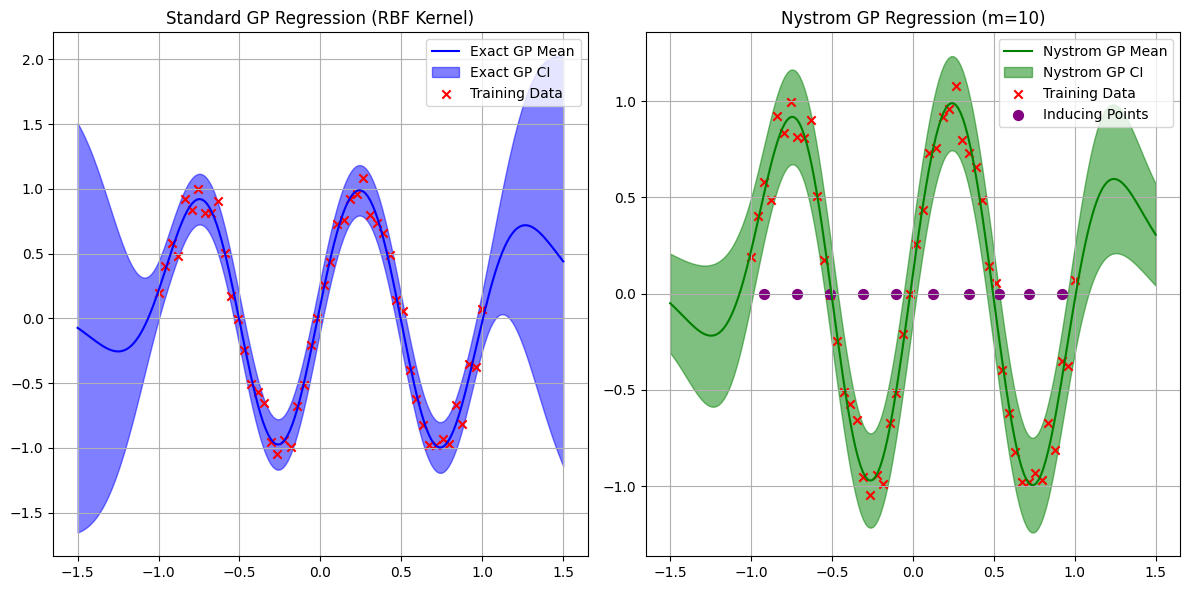

In [ ]:
import torch
import gpytorch
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)


# Generate synthetic 1D data
def generate_data(n_points=50):
    x_train = torch.linspace(-1, 1, n_points).unsqueeze(-1)  # Shape: [n_points, 1]
    y_train = torch.sin(2 * np.pi * x_train.squeeze()) + 0.1 * torch.randn(n_points)
    return x_train, y_train


x_train, y_train = generate_data()


# Define the standard GP Model (for comparison)
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


# Initialize likelihood and model for exact GP
likelihood_exact = gpytorch.likelihoods.GaussianLikelihood()
model_exact = ExactGPModel(x_train, y_train, likelihood_exact)

# --- Nystrom Approximation ---

# 1. Select inducing points using k-means
m = 10  # Number of inducing points
# indices = torch.randperm(len(x_train))[:m]
# inducing_points = x_train[indices]
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=m, random_state=42)
inducing_indices = kmeans.fit_predict(x_train.numpy())
# Use the cluster centers as inducing points
inducing_points = torch.tensor(kmeans.cluster_centers_)


# 2. Define the Nystrom GP Model
class NystromGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, inducing_points):
        super(NystromGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
        self.inducing_points = inducing_points

    def forward(self, x):
        # Get the full covariance matrix
        full_covar = self.covar_module(x)
        # Compute the submatrices
        K_mm = self.covar_module(self.inducing_points)  # m x m
        K_nm = self.covar_module(x, self.inducing_points)  # N x m or M x m

        # --- FIX: Convert Lazy tensors to dense tensors ---
        K_mm_dense = K_mm.evaluate()  # Convert to dense tensor
        K_nm_dense = K_nm.evaluate()  # Convert to dense tensor

        # --- FIX: Add Jitter to K_mm to ensure positive definiteness ---
        jitter_mm = 1e-3
        # K_mm_dense += jitter_mm * torch.eye(K_mm_dense.size(0))
        # jitter_mm = 1e-6
        K_mm_dense += jitter_mm * torch.eye(K_mm_dense.size(0))
        K_mm_inv = torch.linalg.inv(K_mm_dense)

        # Calculate the mean
        mean_x = self.mean_module(x)

        # Calculate the covariance using the Woodbury identity
        # This is equivalent to K_approx + sigma_n^2 I, but computed efficiently
        sigma_n_squared = self.likelihood.noise.item()
        # L = K_nm @ K_mm_inv @ K_nm.T + sigma_n_squared * I
        # We can compute this as: L = sigma_n_squared * I + K_nm @ K_mm_inv @ K_nm.T
        # But for numerical stability, we can use the following approach:
        # Let A = K_nm @ K_mm_inv @ K_nm.T
        A = K_nm_dense @ K_mm_inv @ K_nm_dense.t()
        K_approx = A + sigma_n_squared * torch.eye(A.size(0))

        # Return the distribution
        return gpytorch.distributions.MultivariateNormal(mean_x, K_approx)


# Initialize likelihood and model for Nystrom GP
likelihood_nystrom = gpytorch.likelihoods.GaussianLikelihood()
model_nystrom = NystromGPModel(x_train, y_train, likelihood_nystrom, inducing_points)


# Training the models
def train_model(
    model, likelihood, train_x, train_y, learning_rate=0.1, training_iter=50
):
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

    for i in range(training_iter):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        if (i + 1) % 10 == 0:
            print(f"Iter {i+1}/{training_iter} - Loss: {loss.item():.3f}")


print("Training Standard GP Model...")
train_model(
    model_exact, likelihood_exact, x_train, y_train, learning_rate=0.1, training_iter=50
)

print("\nTraining Nystrom GP Model...")
train_model(
    model_nystrom,
    likelihood_nystrom,
    x_train,
    y_train,
    learning_rate=0.1,
    training_iter=50,
)

# Make predictions and plot results
# Set models to evaluation mode
model_exact.eval()
likelihood_exact.eval()
model_nystrom.eval()
likelihood_nystrom.eval()

# Create test points
test_x = torch.linspace(-1.5, 1.5, 200).unsqueeze(-1)

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Predictions for Exact GP
    exact_observed_pred = likelihood_exact(model_exact(test_x))
    exact_mean = exact_observed_pred.mean
    exact_lower, exact_upper = exact_observed_pred.confidence_region()

    # Predictions for Nystrom GP
    nystrom_observed_pred = likelihood_nystrom(model_nystrom(test_x))
    nystrom_mean = nystrom_observed_pred.mean
    nystrom_lower, nystrom_upper = nystrom_observed_pred.confidence_region()

# Plotting
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(test_x.numpy(), exact_mean.numpy(), "b", label="Exact GP Mean")
plt.fill_between(
    test_x.numpy().flatten(),
    exact_lower.numpy(),
    exact_upper.numpy(),
    alpha=0.5,
    color="b",
    label="Exact GP CI",
)
plt.scatter(
    x_train.numpy(), y_train.numpy(), c="red", marker="x", label="Training Data"
)
plt.title("Standard GP Regression (RBF Kernel)")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(test_x.numpy(), nystrom_mean.numpy(), "g", label="Nystrom GP Mean")
plt.fill_between(
    test_x.numpy().flatten(),
    nystrom_lower.numpy(),
    nystrom_upper.numpy(),
    alpha=0.5,
    color="g",
    label="Nystrom GP CI",
)
plt.scatter(
    x_train.numpy(), y_train.numpy(), c="red", marker="x", label="Training Data"
)
# Plot the inducing points
plt.scatter(
    inducing_points.numpy(),
    np.zeros_like(inducing_points.numpy()),
    c="purple",
    marker="o",
    s=50,
    label="Inducing Points",
)
plt.title(f"Nystrom GP Regression (m={m})")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### **Simple Example: Deep Kernel Learning (DKL) with Inducing Points**

Deep Kernel Learning (DKL) combines the expressiveness of deep neural networks with the probabilistic prediction ability of Gaussian Processes. It uses a deep feature extractor (e.g., a CNN) to transform the input data, and then places a Gaussian Process (approximated with inducing points) on top of the extracted features.

The key advantage of using inducing points is that it retains the non-parametric properties of the GP, leading to better uncertainty estimates, especially for large datasets.

#### **Mathematical Formulation**

Let $f_\theta(\cdot)$ be a deep neural network (feature extractor) parameterized by $\theta$. The kernel function for DKL is defined as:
$$
k(x_i, x_j) = \bar{k}(f_\theta(x_i), f_\theta(x_j))
$$
where $\bar{k}(\cdot, \cdot)$ is a standard kernel (e.g., RBF).

Instead of computing the full $N \times N$ kernel matrix, we use $m$ inducing points $Z = \{z_1, ..., z_m\}$ (which are also in the feature space). The inducing points act as pseudo-input-points used to approximate the full dataset. The locations and values of the inducing points are variational parameters, learned by maximizing a lower bound on the marginal likelihood (the ELBO).

This reduces the complexity of the matrix inversion from $O(N^3)$ to $O(m^2N)$, making models with fewer inducing points faster to train.

In [1]:
import torch
import gpytorch
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)


# Generate synthetic 1D data
def generate_data(n_points=50):
    x_train = torch.linspace(-1, 1, n_points).unsqueeze(-1)  # Shape: [n_points, 1]
    y_train = torch.sin(2 * np.pi * x_train.squeeze()) + 0.1 * torch.randn(n_points)
    return x_train, y_train


x_train, y_train = generate_data()

Training DKL Model...
Iter 10/500 - Loss: 1.417
Iter 20/500 - Loss: 1.280
Iter 30/500 - Loss: 1.194
Iter 40/500 - Loss: 1.146
Iter 50/500 - Loss: 1.122
Iter 60/500 - Loss: 1.106
Iter 70/500 - Loss: 1.093
Iter 80/500 - Loss: 1.061
Iter 90/500 - Loss: 1.020
Iter 100/500 - Loss: 0.988
Iter 110/500 - Loss: 0.974
Iter 120/500 - Loss: 0.959
Iter 130/500 - Loss: 0.950
Iter 140/500 - Loss: 0.945
Iter 150/500 - Loss: 0.942
Iter 160/500 - Loss: 0.941
Iter 170/500 - Loss: 0.940
Iter 180/500 - Loss: 0.938
Iter 190/500 - Loss: 0.937
Iter 200/500 - Loss: 0.936
Iter 210/500 - Loss: 0.935
Iter 220/500 - Loss: 0.934
Iter 230/500 - Loss: 0.934
Iter 240/500 - Loss: 0.933
Iter 250/500 - Loss: 0.933
Iter 260/500 - Loss: 0.932
Iter 270/500 - Loss: 0.931
Iter 280/500 - Loss: 0.931
Iter 290/500 - Loss: 0.930
Iter 300/500 - Loss: 0.930
Iter 310/500 - Loss: 0.930
Iter 320/500 - Loss: 0.930
Iter 330/500 - Loss: 0.929
Iter 340/500 - Loss: 0.929
Iter 350/500 - Loss: 0.929
Iter 360/500 - Loss: 0.929
Iter 370/500 - 

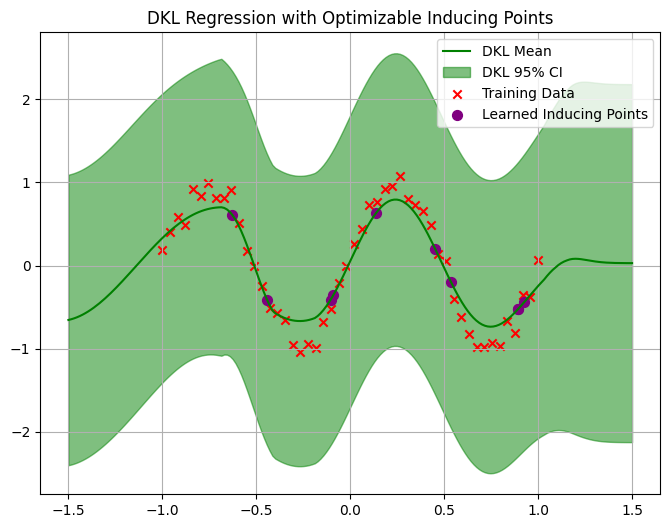

In [9]:
import torch
import gpytorch
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Generate synthetic 1D data
def generate_data(n_points=50):
    x_train = torch.linspace(-1, 1, n_points).unsqueeze(-1)  # Shape: [n_points, 1]
    y_train = torch.sin(2 * np.pi * x_train.squeeze()) + 0.1 * torch.randn(n_points)
    return x_train, y_train

x_train, y_train = generate_data()

# Define a simple feature extractor (a small neural network)
class FeatureExtractor(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(FeatureExtractor, self).__init__()
        self.fc1 = torch.nn.Linear(input_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, output_dim)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Define the DKL Model with Inducing Points
class DKLModel(gpytorch.models.ApproximateGP):
    def __init__(self, train_x, train_y, likelihood, feature_extractor, num_inducing_points=5):
        # Define the variational distribution
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(num_inducing_points)
        ind_points_id = np.random.choice(np.arange(len(train_x)), num_inducing_points, replace=False)
        # Define the variational strategy
        variational_strategy = gpytorch.variational.VariationalStrategy(
            model=self,
            inducing_points=train_x[ind_points_id],#train_x[:num_inducing_points],  # Use the first `num_inducing_points` training points as inducing points
            variational_distribution=variational_distribution,
            learn_inducing_locations=True  # Learn the locations of the inducing points
        )

        # Initialize the base class with the variational strategy
        super(DKLModel, self).__init__(variational_strategy)

        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())
        self.feature_extractor = feature_extractor

    def forward(self, x):
        # Extract features
        features = self.feature_extractor(x)
        # Compute the mean and covariance
        mean_x = self.mean_module(features)
        covar_x = self.covar_module(features)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Initialize the feature extractor
feature_extractor = FeatureExtractor(input_dim=1, hidden_dim=10, output_dim=2)

# Initialize likelihood and model for DKL
likelihood_dkl = gpytorch.likelihoods.GaussianLikelihood()
model_dkl = DKLModel(x_train, y_train, likelihood_dkl, feature_extractor, num_inducing_points=10)

# Training the model
def train_model(model, likelihood, train_x, train_y, learning_rate=0.1, training_iter=50):
    model.train()
    likelihood.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    # Use VariationalELBO for approximate GP models
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=len(train_y))

    for i in range(training_iter):
        optimizer.zero_grad()
        output = model(train_x)
        loss = -mll(output, train_y)
        loss.backward()
        optimizer.step()
        if (i + 1) % 10 == 0:
            print(f'Iter {i+1}/{training_iter} - Loss: {loss.item():.3f}')

print("Training DKL Model...")
train_model(model_dkl, likelihood_dkl, x_train, y_train, learning_rate=0.01, training_iter=500)

# Make predictions and plot results
# Set models to evaluation mode
model_dkl.eval()
likelihood_dkl.eval()

# Create test points
test_x = torch.linspace(-1.5, 1.5, 200).unsqueeze(-1)

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Predictions for DKL
    dkl_observed_pred = likelihood_dkl(model_dkl(test_x))
    dkl_mean = dkl_observed_pred.mean
    dkl_lower, dkl_upper = dkl_observed_pred.confidence_region()

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(test_x.numpy(), dkl_mean.numpy(), 'g', label='DKL Mean')
plt.fill_between(test_x.numpy().flatten(), dkl_lower.numpy(), dkl_upper.numpy(), alpha=0.5, color='g', label='DKL 95% CI')
plt.scatter(x_train.numpy(), y_train.numpy(), c='red', marker='x', label='Training Data')

# Plot the learned inducing points
# Get the inducing point locations from the model
inducing_points = model_dkl.variational_strategy.inducing_points.detach().numpy()

# To get the predicted y-values for the inducing points, we need to evaluate the model at these points.
# We'll use the feature extractor to transform them.
inducing_features = feature_extractor(torch.tensor(inducing_points)).detach().numpy()
# The mean function is constant, so the predicted mean is just the constant mean parameter.
# For simplicity, we can approximate the prediction by evaluating the model's mean module on the inducing features.
# In practice, you would compute the full posterior mean for the inducing points, but for this toy example,
# we'll use the mean of the GP at the inducing point locations.
with torch.no_grad():
    inducing_pred = model_dkl(torch.tensor(inducing_points))
    inducing_mean = inducing_pred.mean.detach().numpy()

plt.scatter(inducing_points, inducing_mean, c='purple', marker='o', s=50, label='Learned Inducing Points')

plt.title('DKL Regression with Optimizable Inducing Points')
plt.legend()
plt.grid(True)
plt.show()